# Métricas de Riesgo — Portafolio de Acciones Chilenas

Cuantificación del riesgo de un universo de nueve acciones del mercado chileno (COPEC, FALABELLA, CMPC, CENCOSUD, ENELCHILE, BSANTANDER, BCI, CAP, AGUAS-A) más el ETF ECH como benchmark, en el período Julio 2024 – Julio 2026.

El análisis cubre tres dimensiones de riesgo fundamentales en la industria:

| Métrica | Pregunta que responde |
|---|---|
| **VaR** | ¿Cuánto puedo perder en un día malo? |
| **CVaR** | ¿Cuánto pierdo en promedio cuando ese día malo ocurre? |
| **Maximum Drawdown** | ¿Cuánto puede caer el capital desde su peak antes de recuperarse? |

Los mismos portafolios optimizados en NB02 (máximo Sharpe, mínima varianza, pesos iguales) sirven como eje de comparación, cerrando el ciclo descriptivo–optimización–riesgo iniciado en NB01.

## 0. Datos

Se descarga el mismo universo de NB01 y NB02: nueve acciones del IPSA más el ETF ECH como benchmark, con datos de cierre diario Julio 2024–Julio 2026. Los precios de cierre son el único insumo — los retornos se calculan como variación porcentual entre cierres consecutivos.

In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
lista_nombre_acciones = ["COPEC.SN", "FALABELLA.SN", "CMPC.SN", "CENCOSUD.SN","ENELCHILE.SN", "BSANTANDER.SN", "BCI.SN","CAP.SN", "AGUAS-A.SN"]
datos_brutos_acciones = yf.download(tickers = lista_nombre_acciones, period = "2y")
lista_nombre_acciones.append("ECH")
ech = yf.download("ECH", period="2y")["Close"]
precios_cierre = datos_brutos_acciones["Close"].copy()
precios_cierre["ECH"] = ech.reindex(precios_cierre.index).ffill().bfill()
precios_cierre

[                       0%                       ]

[***********           22%                       ]  2 of 9 completed

[****************      33%                       ]  3 of 9 completed

[********************* 44%                       ]  4 of 9 completed

[********************* 44%                       ]  4 of 9 completed

[**********************89%******************     ]  8 of 9 completed

[*********************100%***********************]  9 of 9 completed

[*********************100%***********************]  1 of 1 completed

Ticker,AGUAS-A.SN,BCI.SN,BSANTANDER.SN,CAP.SN,CENCOSUD.SN,CMPC.SN,COPEC.SN,ENELCHILE.SN,FALABELLA.SN,ECH
Date,,,,,,,,,,
2024-07-10,239.938339,25027.517578,41.009106,5996.000000,1675.739624,1678.508545,6835.502441,48.915081,2823.163330,25.736309
2024-07-11,246.917526,25489.343750,42.273701,5996.000000,1687.547485,1682.474365,6823.720215,49.540108,2861.573730,25.899015
2024-07-12,248.149155,25447.791016,42.815674,5881.000000,1679.675537,1650.748169,6730.446777,49.277416,2925.910889,26.253141
2024-07-15,248.158279,25962.505859,43.149891,5936.500000,1692.467407,1675.534302,6872.811523,49.277416,2966.241943,26.090437
2024-07-17,248.623535,26146.671875,43.628628,5849.899902,1697.387451,1669.585693,6872.811523,49.458584,2948.093506,25.659740
...,...,...,...,...,...,...,...,...,...,...
2026-07-06,333.000000,60637.000000,76.940002,6247.000000,2095.000000,1046.900024,5880.000000,81.000000,5781.000000,39.660000
2026-07-07,336.850006,63000.000000,78.500000,6359.600098,2081.000000,1075.000000,6050.000000,81.900002,6000.000000,39.889999
2026-07-08,334.239990,62967.000000,77.099998,6280.500000,2079.000000,1078.599976,6030.000000,81.949997,5880.000000,39.189999


## 1. Value at Risk (VaR)

El **VaR al X%** es la pérdida máxima esperada en un día normal con probabilidad (1-X%). Un VaR 95% de -2% significa que solo el 5% de los días la pérdida supera ese umbral.

Se comparan tres métodos de estimación:

- **Histórico:** percentil empírico de la distribución de retornos. No asume ninguna distribución subyacente.
- **Paramétrico:** `mu - z*sigma`, con z = 1.645 (95%) o z = 2.326 (99%). Asume normalidad.
- **Monte Carlo:** 10.000 retornos simulados desde una distribución normal con los parámetros históricos; percentil 5% de la simulación.

La divergencia entre el método histórico y el paramétrico es el diagnóstico directo de la leptokurtosis documentada en NB01.

In [3]:
retorno = precios_cierre.pct_change()

retornos_95 = retorno[retorno <  retorno.quantile(0.05)] * 100
retornos_99 = retorno[retorno <  retorno.quantile(0.01)] * 100

media = retorno.mean()
dst = retorno.std()
parametrico_95 = (-1.645*dst + media)*100
parametrico_99 = (-2.326*dst + media)*100

mc_95 = {}
mc_99 = {}

np.random.seed(42)
for i in retorno.columns:
    mc = np.random.normal(media[i], dst[i], 10000)
    mc.sort()
    mc_95[i] = np.quantile(mc, 0.05)*100
    mc_99[i] = np.quantile(mc, 0.01)*100
    

pd.DataFrame({"VaR Histórico 95 [%]": retorno.quantile(0.05) * 100, 
              "VaR Paramétrico 95 [%]" : parametrico_95,
              "VaR Monte Carlo 95 [%]" : mc_95,
              "VaR Histórico 99 [%]": retorno.quantile(0.01) * 100,
              "VaR Paramétrico 99 [%]": parametrico_99,
              "VaR Monte Carlo 99 [%]": mc_99})

,VaR Histórico 95 [%],VaR Paramétrico 95 [%],VaR Monte Carlo 95 [%],VaR Histórico 99 [%],VaR Paramétrico 99 [%],VaR Monte Carlo 99 [%]
AGUAS-A.SN,-1.884376,-1.963337,-1.975567,-3.262081,-2.808213,-2.801443
BCI.SN,-2.419044,-2.515113,-2.456189,-3.643769,-3.639873,-3.725120
BSANTANDER.SN,-1.927970,-1.993881,-1.957508,-2.881721,-2.877653,-2.846805
CAP.SN,-2.677827,-2.740730,-2.750142,-3.960902,-3.888968,-3.937290
CENCOSUD.SN,-2.836775,-2.760919,-2.776135,-3.915373,-3.926593,-3.972202
CMPC.SN,-3.016737,-2.961671,-3.006488,-4.001177,-4.159479,-4.268579
COPEC.SN,-2.402141,-2.489599,-2.451613,-3.751791,-3.515948,-3.430813
ENELCHILE.SN,-2.191872,-2.254618,-2.254341,-3.220927,-3.235184,-3.198627
FALABELLA.SN,-2.713906,-2.703370,-2.731739,-3.712366,-3.890537,-3.912646
ECH,-2.375991,-2.322058,-2.320768,-3.952869,-3.325149,-3.314053


## 2. CVaR — Expected Shortfall

El **CVaR (Conditional Value at Risk)** o Expected Shortfall responde: cuando el VaR se supera, ¿cuánto se pierde en promedio?

Se calcula filtrando solo los retornos peores que el umbral VaR y tomando su promedio. Siempre es más negativo que el VaR correspondiente.

In [4]:
pd.DataFrame({"CVaR 95 [%]": retornos_95.mean(),
              "CVaR 99 [%]": retornos_99.mean()})

,CVaR 95 [%],CVaR 99 [%]
Ticker,,
AGUAS-A.SN,-2.756742,-4.337331
BCI.SN,-3.186083,-4.491773
BSANTANDER.SN,-2.645590,-3.516035
CAP.SN,-3.646835,-5.149615
CENCOSUD.SN,-3.673515,-5.145293
CMPC.SN,-3.610471,-4.308435
COPEC.SN,-3.151286,-4.223111
ENELCHILE.SN,-2.943325,-4.070274
FALABELLA.SN,-3.406718,-4.709430


## 3. Maximum Drawdown

El **Maximum Drawdown** mide la caída máxima desde un peak histórico hasta el valle siguiente, antes de recuperarse. Responde: ¿cuánto puede caer el capital en un período sostenido?

Se calcula comparando cada precio con el máximo acumulado hasta ese día (`cummax`). El mínimo de esa serie es el Maximum Drawdown.

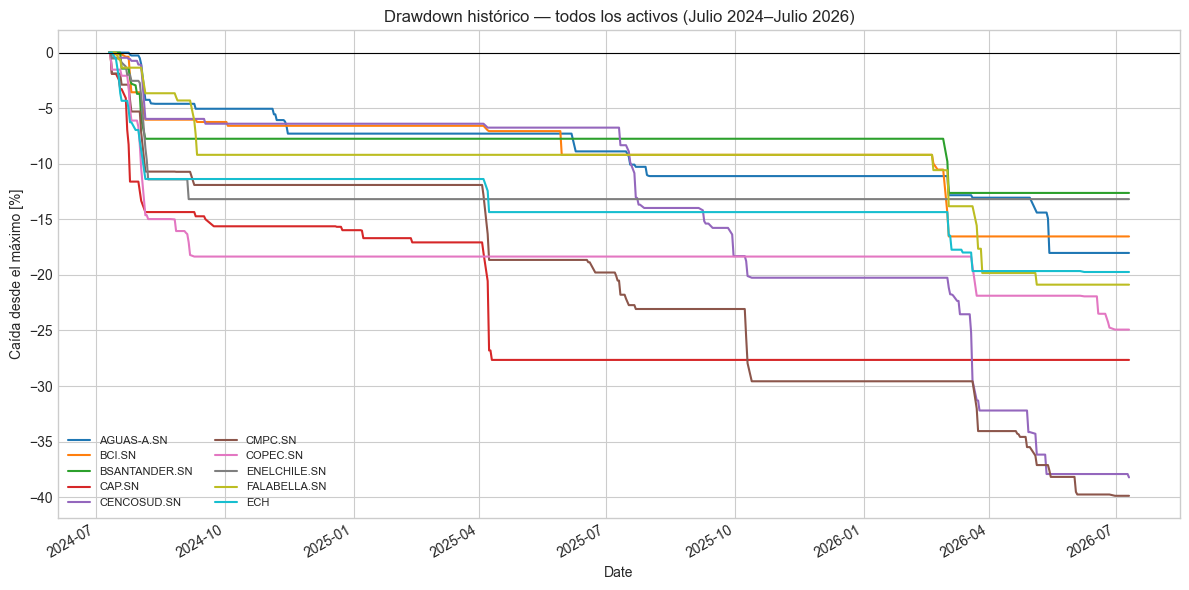

In [5]:
drawdown = ((precios_cierre - precios_cierre.cummax())/precios_cierre.cummax()) * 100
drawrecto = drawdown.cummin()
plt.style.use('seaborn-v0_8-whitegrid')
fig, dw = plt.subplots(figsize=(12, 6))
dw.set_title("Drawdown histórico — todos los activos (Julio 2024–Julio 2026)")
dw.set_ylabel("Caída desde el máximo [%]")
dw.set_xlabel("Fecha")
drawrecto.plot(ax=dw)
dw.axhline(0, color="black", linewidth=0.8)
dw.legend(loc='lower left', ncol=2, fontsize=8)
plt.tight_layout()

C:\Users\pablo\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\plotting\_matplotlib\core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
C:\Users\pablo\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\plotting\_matplotlib\core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
C:\Users\pablo\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\plotting\_matplotlib\core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)
C:\Users\pablo\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\plotting\_matplotlib\core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*ar

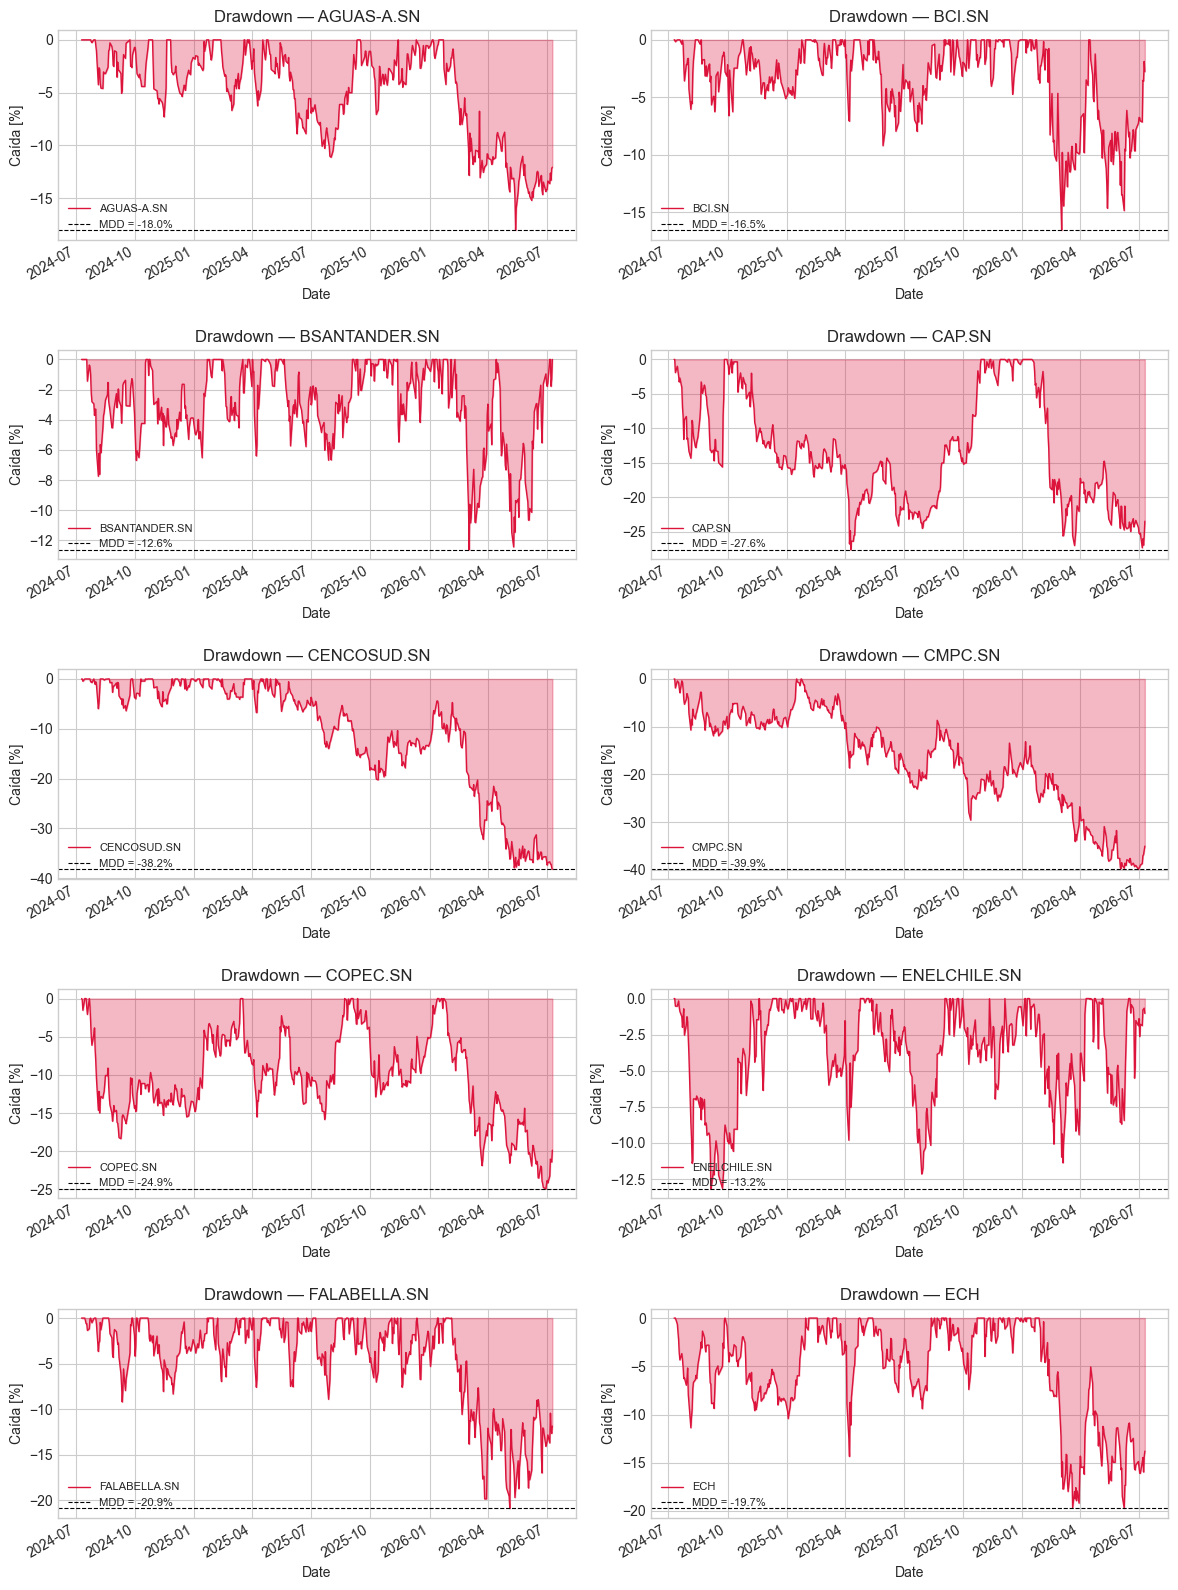

In [6]:
x = 0
y = 0

plt.style.use('seaborn-v0_8-whitegrid')
fig, dwo = plt.subplots(5, 2, figsize=(12, 16))
for i in retorno.columns:
    dwo[x][y].set_title("Drawdown — " + i)
    dwo[x][y].set_ylabel("Caída [%]")
    dwo[x][y].set_xlabel("Fecha")
    dwo[x][y].fill_between(drawdown.index, drawdown[i], 0, color="crimson", alpha=0.3)
    drawdown[i].plot(ax=dwo[x][y], color="crimson", linewidth=1)
    dwo[x][y].axhline(drawdown[i].min(), color="black", linewidth=0.8, linestyle="--",
                      label="MDD = {:.1f}%".format(drawdown[i].min()))
    dwo[x][y].legend(loc="lower left", fontsize=8)

    if y == 1:
        y = 0
        x += 1
    else:
        y += 1
plt.tight_layout(h_pad=2)

In [7]:
pd.DataFrame({"MDD [%]": drawdown.min()})

,MDD [%]
Ticker,
AGUAS-A.SN,-18.023628
BCI.SN,-16.540102
BSANTANDER.SN,-12.625622
CAP.SN,-27.647059
CENCOSUD.SN,-38.213974
CMPC.SN,-39.870137
COPEC.SN,-24.919766
ENELCHILE.SN,-13.183400
FALABELLA.SN,-20.877682


## 4. Riesgo de portafolio

Los tres portafolios construidos en NB02 (máximo Sharpe, mínima varianza, pesos iguales) se evalúan como unidades de inversión. Los retornos diarios de cada portafolio se calculan como la suma ponderada de los retornos individuales: `r_p = sum(w_i * r_i)`.

La diversificación reduce el riesgo por debajo del promedio ponderado de los activos individuales. La pregunta central: ¿cuánto protege cada estrategia en los peores días, y a qué costo en retorno ajustado?

### Pesos de NB02

Los pesos de los tres portafolios optimizados en NB02 se cargan desde el archivo CSV exportado en esa sesión. Esto garantiza que el análisis de riesgo use exactamente los mismos pesos que produjo la optimización — sin re-derivarlos ni introducir diferencias numéricas.

In [8]:
dataframe_pesos = pd.read_csv("pesos_nb02.csv", index_col = 0)
dataframe_pesos

,Máximo Sharpe,Mínima Varianza,Pesos iguales
AGUAS-A.SN,1.125587e-01,0.337793,0.111111
BCI.SN,3.706705e-01,0.007850,0.111111
BSANTANDER.SN,2.385894e-01,0.149127,0.111111
CAP.SN,5.624722e-17,0.157619,0.111111
CENCOSUD.SN,6.227810e-17,0.090375,0.111111
CMPC.SN,0.000000e+00,0.000371,0.111111
COPEC.SN,0.000000e+00,0.088616,0.111111
ENELCHILE.SN,1.231089e-01,0.168250,0.111111
FALABELLA.SN,1.550725e-01,0.000000,0.111111


In [9]:
retornos_max_shr = retorno[dataframe_pesos.index] @ dataframe_pesos["Máximo Sharpe"]
retornos_min_var = retorno[dataframe_pesos.index] @ dataframe_pesos["Mínima Varianza"]
retornos_pes_ig = retorno[dataframe_pesos.index] @ dataframe_pesos["Pesos iguales"]

retornos_shr_95 = retornos_max_shr[retornos_max_shr <  retornos_max_shr.quantile(0.05)] * 100
retornos_min_var_95 = retornos_min_var[retornos_min_var <  retornos_min_var.quantile(0.05)] * 100
retornos_ig_95 = retornos_pes_ig[retornos_pes_ig <  retornos_pes_ig.quantile(0.05)] * 100

retornos_shr_99 = retornos_max_shr[retornos_max_shr <  retornos_max_shr.quantile(0.01)] * 100
retornos_min_var_99 = retornos_min_var[retornos_min_var <  retornos_min_var.quantile(0.01)] * 100
retornos_ig_99 = retornos_pes_ig[retornos_pes_ig <  retornos_pes_ig.quantile(0.01)] * 100

capital_pesos = precios_cierre[dataframe_pesos.index] @ dataframe_pesos

drawdown_pesos = ((capital_pesos - capital_pesos.cummax())/capital_pesos.cummax()) * 100

sharpe_max = ((retornos_max_shr.mean() - 0.055/252)/retornos_max_shr.std())*np.sqrt(252)
sharpe_min_var = (retornos_min_var.mean() - 0.055/252)/retornos_min_var.std()*np.sqrt(252)
sharpe_pes_ig = (retornos_pes_ig.mean() - 0.055/252)/retornos_pes_ig.std()*np.sqrt(252)
sharpe_ech = (retorno["ECH"].mean() - 0.055/252)/retorno["ECH"].std()*np.sqrt(252)


pd.DataFrame({"VaR 95 [%]": [retornos_max_shr.quantile(0.05) * 100, retornos_min_var.quantile(0.05) * 100, retornos_pes_ig.quantile(0.05) * 100, retorno["ECH"].quantile(0.05) * 100],
              "CVaR 95 [%]": [retornos_shr_95.mean(), retornos_min_var_95.mean(), retornos_ig_95.mean(), retornos_95["ECH"].mean()],
              "VaR 99 [%]": [retornos_max_shr.quantile(0.01) * 100, retornos_min_var.quantile(0.01) * 100, retornos_pes_ig.quantile(0.01) * 100, retorno["ECH"].quantile(0.01) * 100],
              "CVaR 99 [%]": [retornos_shr_99.mean(), retornos_min_var_99.mean(), retornos_ig_99.mean(), retornos_99["ECH"].mean()],
              "MDD [%]": [drawdown_pesos["Máximo Sharpe"].min(), drawdown_pesos["Mínima Varianza"].min(), drawdown_pesos["Pesos iguales"].min(), drawdown["ECH"].min()],
              "Ratio de Sharpe" : [sharpe_max, sharpe_min_var, sharpe_pes_ig, sharpe_ech]}, 
              index= ["Máximo Sharpe", "Mínima Varianza", "Pesos iguales", "ECH"])

,VaR 95 [%],CVaR 95 [%],VaR 99 [%],CVaR 99 [%],MDD [%],Ratio de Sharpe
Máximo Sharpe,-1.729043,-2.224329,-2.497812,-3.156145,-16.293017,1.914174
Mínima Varianza,-1.342351,-1.992696,-2.567091,-3.117992,-21.633867,1.008346
Pesos iguales,-1.563889,-2.087019,-2.562025,-3.145141,-15.912386,0.935200
ECH,-2.375991,-3.393977,-3.952869,-4.751144,-19.738225,0.853013


## 5. Los peores días

Los diez peores días del portafolio de máximo Sharpe, con el retorno simultáneo del benchmark ECH. Permite distinguir si las caídas son idiosincrásicas (locales al mercado chileno) o sistémicas (presentes también en el benchmark global).

In [10]:
ten_peores = pd.DataFrame({"Portafolio Óptimo [%]":retornos_max_shr.nsmallest(10)*100, 
                           "ECH [%]": retorno["ECH"]*100}
                           ).sort_values("Portafolio Óptimo [%]", ascending=True)
ten_peores_r = ten_peores.dropna().reset_index()
ten_peores_r.index += 1
ten_peores_r

,Date,Portafolio Óptimo [%],ECH [%]
1,2026-03-02,-4.464288,-4.459768
2,2025-04-07,-3.204516,-3.902099
3,2026-03-03,-2.881371,-4.788260
4,2025-04-04,-2.667976,-6.252082
5,2024-08-05,-2.562574,-2.876543
6,2025-11-13,-2.493678,-1.476116
7,2026-03-05,-2.331791,-3.324243
8,2026-02-13,-2.202690,-0.994344
9,2026-02-10,-2.161598,-3.530418
10,2026-04-21,-2.158474,-3.487324


## 6. Conclusiones

### Comparación de métodos: histórico vs paramétrico

El VaR paramétrico asume distribución normal. NB01 documentó leptokurtosis en los 10 activos analizados (todos rechazan normalidad con el test Jarque-Bera). La consecuencia directa: el paramétrico subestima el riesgo en las colas extremas. La divergencia entre métodos es modesta al 95%, pero se amplifica al 99%, precisamente donde la kurtosis importa. Los activos con mayor exceso de kurtosis (AGUAS-A, CAP) muestran las brechas más pronunciadas entre VaR histórico y paramétrico.

### Beneficio de la diversificación

La diversificación reduce el riesgo de manera significativa. El VaR 95% promedio de los activos individuales es -2.45%; el mejor portafolio en esta métrica (mínima varianza) alcanza -1.34%, una reducción de ~45%. Este resultado ilustra el principio central de Markowitz: combinar activos con correlaciones imperfectas reduce la volatilidad total por debajo del promedio ponderado de las volatilidades individuales.

### Trade-off: máximo Sharpe vs mínima varianza

| Portafolio | Sharpe | VaR 95% | CVaR 95% | VaR 99% | CVaR 99% | MDD |
|---|---|---|---|---|---|---|
| Máximo Sharpe | 1.91 | -1.73% | -2.22% | -2.50% | -3.16% | -16.3% |
| Mínima Varianza | 1.01 | -1.34% | -1.99% | -2.57% | -3.12% | -21.6% |
| Pesos iguales | 0.94 | -1.56% | -2.09% | -2.56% | -3.15% | -15.9% |
| ECH (benchmark) | 0.85 | -2.38% | -3.39% | -3.95% | -4.75% | -19.7% |

La mínima varianza sigue dominando en VaR y CVaR (días malos típicos y su severidad promedio), pero pierde esa ventaja en drawdown: con esta ventana de datos, su MDD (-21.6%) es el **peor de los cuatro**, incluso más profundo que el del benchmark pasivo ECH (-19.7%). Es un hallazgo distinto al de la corrida anterior, donde mínima varianza superaba a ECH en las tres métricas. La explicación de fondo no cambia: minimizar la varianza (segundo momento) reduce la dispersión día a día, pero no protege contra una caída sostenida que se acumula a lo largo de varios meses — el drawdown es una medida de trayectoria, no de dispersión puntual. El máximo Sharpe, en cambio, domina en las seis métricas simultáneamente y entrega una ratio de rentabilidad ajustada por riesgo ~1.9x superior a la de mínima varianza (1.91 vs 1.01).

**Nota:** el Sharpe de esta tabla (1.91) se recalcula directamente sobre los retornos diarios del portafolio con la tasa libre de riesgo, y coincide con el Sharpe real anualizado que reporta NB02 (2.22 sin rf / 1.91 con rf). Al estar ambos notebooks sobre la misma ventana de datos, las dos metodologías de cálculo reconcilian en 1.91.

### Limitaciones

- **VaR histórico:** asume que el futuro se parece al pasado. Una ventana de dos años puede no capturar regímenes de estrés no observados.
- **Covarianza estática:** los pesos se calcularon con correlaciones históricas fijas. En crisis, las correlaciones tienden a subir, deteriorando la diversificación cuando más se necesita.
- **Sensibilidad a la ventana de datos:** al comparar esta corrida con la anterior, tanto el ranking de Sharpe como el de MDD entre portafolios cambiaron de forma no trivial (mínima varianza pasó de superar a ECH en MDD a quedar por debajo). Esto confirma que los resultados de este notebook son sensibles al punto exacto de corte de los datos, no solo al período analizado en términos generales.
- **Sin out-of-sample:** el mismo período se usa para calibrar y evaluar. NB04 abordará esto mediante backtesting con walk-forward validation.